In [ ]:
import json                                                                                                                                                                                                                                          
import random
from pathlib import Path

%matplotlib inline
import matplotlib.patches as patches
import matplotlib.pyplot as plt                                                                                                                                                                                                                      
import numpy as np
import torch
import torchvision.transforms.functional as TF
from PIL import Image                                                                                                                                                                                                                                
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection import MeanAveragePrecision                                                                                                                                                                                              

In [ ]:
# Manual Seed for Reproducibility
STUDENT_ID = 26045171
                                                                                                                                                                                                                                                                                                                                                                                                          
torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)                                                                                                                                                                                                                              
np.random.seed(STUDENT_ID)                                                                                                                                                                                                                           

DATASET_ROOT = Path("26045171/Object_Detection/coco")                                                                                                                                                                                                
RUNS_DIR     = Path("runs/exp3_fasterrcnn_v2")
RUNS_DIR.mkdir(parents=True, exist_ok=True)                                                                                                                                                                                                          
              
# torchvision reserves class index 0 for background, so our 5 lettuce                                                                                                                                                                                
# classes map to indices 1–5, which conveniently matches COCO's 1-indexed IDs.
CLASS_NAMES = ["__background__", "Ready", "empty_pod", "germination", "pod", "young"]                                                                                                                                                                
NUM_CLASSES = len(CLASS_NAMES)  # 6
                                                                                                                                                                                                                                                   
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | Classes: {NUM_CLASSES}")

Device: cuda | Classes: 6


In [ ]:
class LettuceDataset(Dataset):
    def __init__(self, img_dir, ann_file):                                                                                                                                                                                            
        self.img_dir = Path(img_dir)

        with open(ann_file) as f:                                                                                                                                                                                                                    
            coco = json.load(f)
                                                                                                                                                                                                                                       
        # Create image_id to annotations dictionary for efficient lookup in __getitem__
        self.ann_by_img = {}
        for ann in coco["annotations"]:                                                                                                                                                                                                              
            self.ann_by_img.setdefault(ann["image_id"], []).append(ann)

        self.images = []
        self.unannotated_count = 0

        # Keep images that have annotations
        # Report unannotated images for debugging
        for img in coco["images"]:
            if img["id"] in self.ann_by_img:
                self.images.append(img)
            else:
                self.unannotated_count += 1

    def details(self):
        return f"With annotations: {len(self.images):<4} | Unannotated: {self.unannotated_count:<4}"

    def __len__(self):                                                                                                                                                                                                                               
        return len(self.images)

    def __getitem__(self, idx):
        img_metadata = self.images[idx]
        img  = Image.open(self.img_dir / img_metadata["file_name"]).convert("RGB")                                                                                                                                                                           
                                                                                                                                                                                                                 
        boxes, labels = [], []
        for ann in self.ann_by_img[img_metadata["id"]]:                                                                                                                                                                                                      
            x, y, w, h = ann["bbox"]

            if w <= 0 or h <= 0 or ann["category_id"] not in range(1, NUM_CLASSES):                                                                                                                                                                                                                     
                continue  # skip malformed annotations and invalid category IDs

            # Convert COCO [x, y, w, h] to [x1, y1, x2, y2]                                                                                                                                                                                           
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

        target = {                                                                                                                                                                                                                                   
            "boxes":    torch.as_tensor(boxes,  dtype=torch.float32),                                                                                                                                                                                
            "labels":   torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_metadata["id"]]),                                                                                                                                                                                                  
        }

        img = TF.to_tensor(img)
   
        return img, target

In [ ]:
def collate_fn(batch):                                                                                                                                                                                                                               
    return tuple(zip(*batch))                                                                                                                                                                                                                        

train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json")                                                                                                                                                                                                              
val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")                                                                                                                                                                         
test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)

print(f"TRAIN:      | {train_ds.details()}")
print(f"VALIDATION: | {val_ds.details()}")
print(f"TEST:       | {test_ds.details()}")

Train: 1050 | Val: 224 | Test: 226


In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_faster_rcnn(num_classes):
    # Load Faster-RCNN with a ResNet-50 + FPN backbone pretrained on COCO.
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT                                                                                                                                                                           
    model = fasterrcnn_resnet50_fpn(weights=weights)                                                                                                                                                                                           

    # Get the number of input features for the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # The pretrained head predicts 91 COCO classes.
    # We replace it with a new one for our 6 classes.                                                                                                                                                                            
    # The backbone weights are kept and will be fine-tuned on our data.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)                                                                                                                                                                      
                                                                                                                                                                                                                           
    return model

model = build_faster_rcnn(NUM_CLASSES).to(DEVICE)

Total params:     41,319,661
Trainable params: 41,097,261


In [ ]:
def train_one_epoch(model, loader, optimizer):
    # Set the model to training mode                                                                                                                                                                                                                 
    model.train()                                                                                                                                                                                                                          
    running_loss = 0.0                                                                                                                                                                                                                               
 
    for images, targets in loader:
        # Move all images and targets to the selected device
        images  = [img.to(DEVICE) for img in images]                          
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)  # Get the loss dict from the model
        loss      = sum(loss_dict.values()) # Combine all losses into a single scalar
                                                                                                                                                                                                                      
        optimizer.zero_grad()
        loss.backward()                                                                                                                                                                             
        optimizer.step()
                                                                                                                                                                                                                                                      
        running_loss += loss.item()
    return running_loss / len(loader)

In [ ]:
@torch.no_grad()
def evaluate_map50(model, loader):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5], class_metrics=True)
    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)
        metric.update(
            [{k: v.cpu() for k, v in p.items()} for p in preds],
            [{k: v.cpu() for k, v in t.items()} for t in targets],
        )
    return metric.compute()


@torch.no_grad()
def evaluate_full(model, loader):
    """Full COCO evaluation across IoU 0.50:0.95 — used only on the test set."""
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)
        metric.update(
            [{k: v.cpu() for k, v in p.items()} for p in preds],
            [{k: v.cpu() for k, v in t.items()} for t in targets],
        )
    return metric.compute()

In [8]:
@torch.no_grad()
def compute_val_loss(model, loader):
    model.train()  # training mode so the model returns a loss dict instead of predictions
    total_loss = 0.0
    for images, targets in loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        total_loss += sum(loss_dict.values()).item()
    return total_loss / len(loader)

In [ ]:
optimizer = torch.optim.SGD(
    model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4
)

EPOCHS   = 300
PATIENCE = 30

best_map50       = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_map50": [], "val_map50": []}

for epoch in range(1, EPOCHS + 1):
    train_loss    = train_one_epoch(model, train_loader, optimizer)
    val_loss      = compute_val_loss(model, val_loader)
    train_metrics = evaluate_map50(model, train_loader)
    val_metrics   = evaluate_map50(model, val_loader)

    train_map50 = train_metrics["map_50"].item()
    val_map50   = val_metrics["map_50"].item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_map50"].append(train_map50)
    history["val_map50"].append(val_map50)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"mAP@50={train_map50:.4f}/{val_map50:.4f}")

    if val_map50 > best_map50:
        best_map50 = val_map50
        patience_counter = 0
        torch.save(model.state_dict(), RUNS_DIR / "best.pth")
        print(f"  → Best saved (mAP@50={best_map50:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break


Epoch   1/300  loss=0.9299/0.5921  mAP@50=0.8240  lr=1.00e-03
  → Best saved (mAP@50=0.8240)
Epoch   2/300  loss=0.5530/0.4967  mAP@50=0.8921  lr=1.00e-03
  → Best saved (mAP@50=0.8921)
Epoch   3/300  loss=0.4763/0.4589  mAP@50=0.9081  lr=1.00e-03
  → Best saved (mAP@50=0.9081)
Epoch   4/300  loss=0.4367/0.4623  mAP@50=0.8993  lr=1.00e-03
Epoch   5/300  loss=0.4035/0.4428  mAP@50=0.9234  lr=9.99e-04
  → Best saved (mAP@50=0.9234)
Epoch   6/300  loss=0.3784/0.4215  mAP@50=0.9255  lr=9.99e-04
  → Best saved (mAP@50=0.9255)
Epoch   7/300  loss=0.3550/0.4258  mAP@50=0.9238  lr=9.99e-04
Epoch   8/300  loss=0.3381/0.4276  mAP@50=0.9327  lr=9.98e-04
  → Best saved (mAP@50=0.9327)
Epoch   9/300  loss=0.3199/0.4305  mAP@50=0.9297  lr=9.98e-04
Epoch  10/300  loss=0.3045/0.4194  mAP@50=0.9356  lr=9.97e-04
  → Best saved (mAP@50=0.9356)
Epoch  11/300  loss=0.2896/0.4280  mAP@50=0.9282  lr=9.97e-04
Epoch  12/300  loss=0.2762/0.4239  mAP@50=0.9317  lr=9.96e-04
Epoch  13/300  loss=0.2637/0.4469  mAP@

In [10]:
# Reload the best checkpoint (not the last epoch) to report final numbers
model.load_state_dict(torch.load(RUNS_DIR / "best.pth", map_location=DEVICE))
test_metrics = evaluate_full(model, test_loader)

print("=== TEST SET RESULTS ===")
print(f"mAP@50:    {test_metrics['map_50'].item():.4f}")
print(f"mAP@50-95: {test_metrics['map'].item():.4f}")
print(f"Recall:    {test_metrics['mar_100'].item():.4f}")

print("\nPer-class AP@50:")
for name, ap in zip(CLASS_NAMES[1:], test_metrics["map_per_class"]):
    print(f"  {name:15s}: {ap:.4f}")

=== TEST SET RESULTS ===
mAP@50:    0.9405
mAP@50-95: 0.6535
Precision: tensor([0.4592, 0.6997, 0.7367, 0.7402, 0.6317])
Recall:    0.7407

Per-class AP@50:
  Ready          : 0.4592
  empty_pod      : 0.6997
  germination    : 0.7367
  pod            : 0.7402
  young          : 0.6317


In [11]:
print(test_metrics.keys())

dict_keys(['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large', 'map_per_class', 'mar_100_per_class', 'classes'])


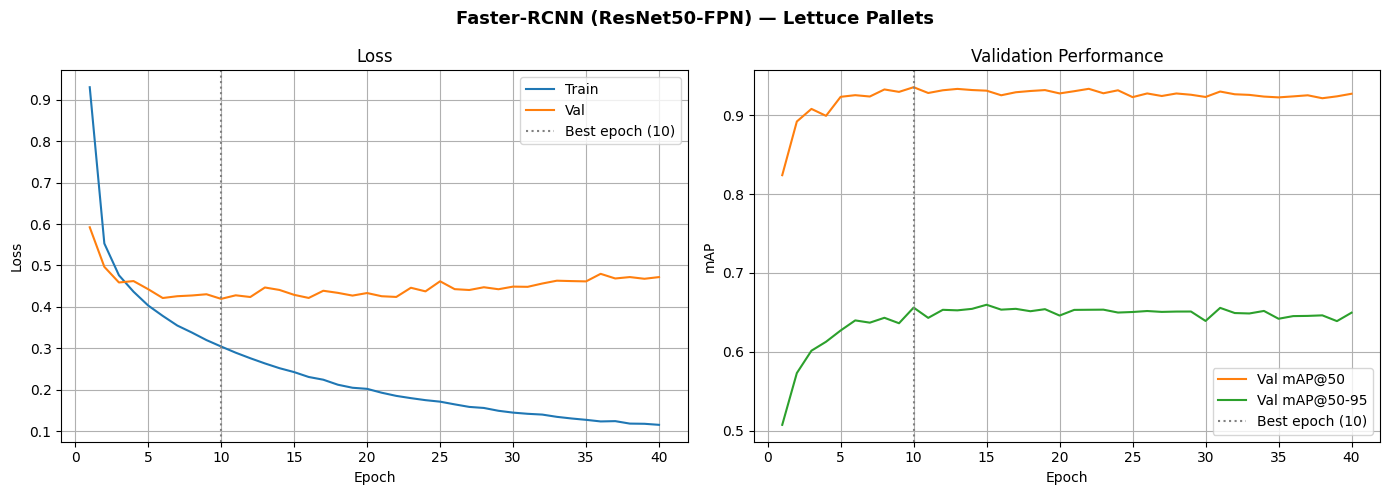

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x   = range(1, len(history["train_loss"]) + 1)
best_epoch = int(np.argmax(history["val_map50"])) + 1

ax1.plot(epochs_x, history["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, history["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_x, history["train_map50"], label="Train mAP@50", color="tab:blue")
ax2.plot(epochs_x, history["val_map50"],   label="Val mAP@50",   color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax2.set(xlabel="Epoch", ylabel="mAP@50", title="mAP@50")
ax2.legend()
ax2.grid(True)

plt.suptitle("Faster-RCNN (ResNet50-FPN) — Lettuce Pallets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RUNS_DIR / "training_curves.png", dpi=150)
plt.show()

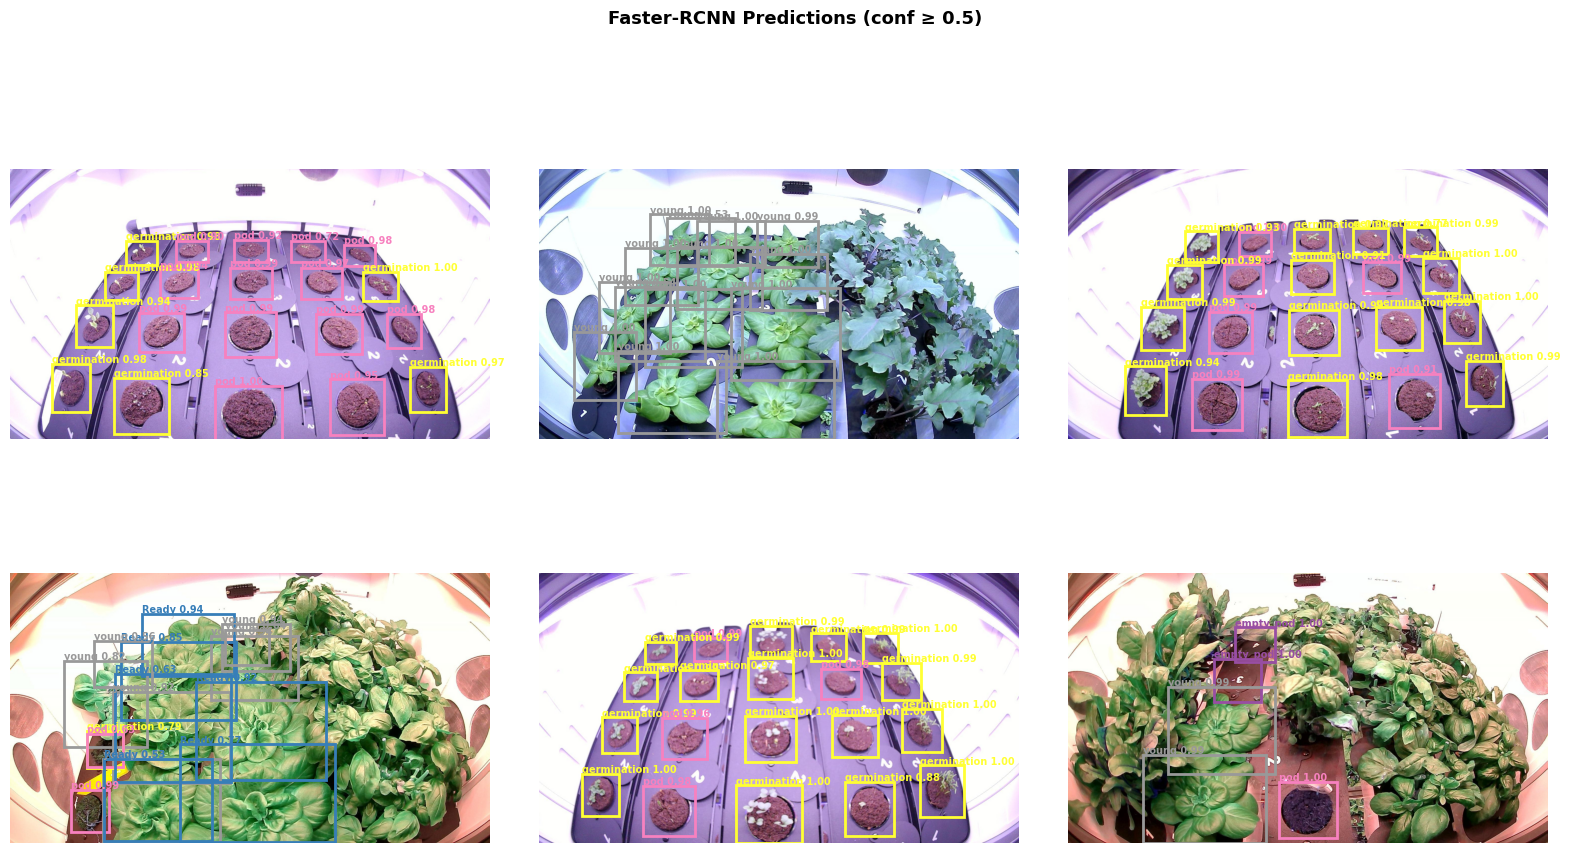

In [13]:
@torch.no_grad()
def plot_predictions(model, dataset, n=6, conf=0.5, seed=STUDENT_ID):                                                                                                                                                                                
    model.eval()                                                                                                                                                                                                                                     
    random.seed(seed)
    indices = random.sample(range(len(dataset)), n)                                                                                                                                                                                                  
    colors  = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))                                                                                                                                                                                            
                                                                                                                                                                                                                                                   
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))                                                                                                                                                                                                 
    for ax, idx in zip(axes.flatten(), indices):                                                                                                                                                                                                     
        img_tensor, _ = dataset[idx]                                                                                                                                                                                                                 
        pred = model([img_tensor.to(DEVICE)])[0]
                                                                                                                                                                                                                                                   
        ax.imshow(img_tensor.permute(1, 2, 0).numpy())
        for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):                                                                                                                                                                 
            if score < conf:                                                                                                                                                                                                                         
                continue
            x1, y1, x2, y2 = box.cpu().tolist()                                                                                                                                                                                                      
            cls = label.item()                                                                                                                                                                                                                       
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,                                                                                                                                                                                                          
                linewidth=2, edgecolor=colors[cls], facecolor="none"
            ))                                                                                                                                                                                                                                       
            ax.text(x1, y1 - 4, f"{CLASS_NAMES[cls]} {score:.2f}",
                    color=colors[cls], fontsize=7, fontweight="bold")
        ax.axis("off")

    plt.suptitle(f"Faster-RCNN Predictions (conf ≥ {conf})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RUNS_DIR / "predictions.png", dpi=150)
    plt.show()

plot_predictions(model, test_ds)

In [ ]:
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead

# All constants (CLASS_NAMES, NUM_CLASSES, DEVICE, STUDENT_ID) are shared
# with Exp 3 — reuse them from the earlier cells.

SSD_RUNS_DIR = Path("runs/exp4_ssd_v2")
SSD_RUNS_DIR.mkdir(parents=True, exist_ok=True)

def build_ssd(num_classes):
    # SSD300 pretrained on COCO 2017 — same pretraining dataset as Faster-RCNN,
    # making the comparison fair in terms of prior knowledge given to each model.
    weights = SSD300_VGG16_Weights.DEFAULT
    model   = ssd300_vgg16(weights=weights)

    # Replace only the classification head for our number of classes.
    # The backbone and box regression head keep their COCO pretrained weights.
    in_channels = [c.in_channels for c in model.head.classification_head.module_list]
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(
        in_channels, num_anchors, num_classes
    )

    return model

ssd_model = build_ssd(NUM_CLASSES).to(DEVICE)

total     = sum(p.numel() for p in ssd_model.parameters())
trainable = sum(p.numel() for p in ssd_model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

Total params:     24,280,556
Trainable params: 24,241,836


In [ ]:
# Same dataset class as Faster-RCNN — no manual resizing needed since SSD300
# resizes all images internally to 300×300 via GeneralizedRCNNTransform.
# Batch=64 is justified by SSD's fixed small input (300×300 vs Faster-RCNN's
# ~800×1333) — the smaller resolution fits more images in GPU memory.
# Faster-RCNN at batch=4 and SSD at batch=64 are each at their practical
# optimum; the different batch sizes do not make the comparison unfair.

ssd_train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json")
ssd_val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")
ssd_test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")

ssd_train_loader = DataLoader(ssd_train_ds, batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)
ssd_val_loader   = DataLoader(ssd_val_ds,   batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)
ssd_test_loader  = DataLoader(ssd_test_ds,  batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)

In [ ]:
ssd_optimizer = torch.optim.SGD(
    ssd_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4
)

EPOCHS   = 300
PATIENCE = 30

best_map50       = 0.0
patience_counter = 0
ssd_history = {"train_loss": [], "val_loss": [], "train_map50": [], "val_map50": []}

for epoch in range(1, EPOCHS + 1):
    train_loss    = train_one_epoch(ssd_model, ssd_train_loader, ssd_optimizer)
    val_loss      = compute_val_loss(ssd_model, ssd_val_loader)
    train_metrics = evaluate_map50(ssd_model, ssd_train_loader)
    val_metrics   = evaluate_map50(ssd_model, ssd_val_loader)

    train_map50 = train_metrics["map_50"].item()
    val_map50   = val_metrics["map_50"].item()

    ssd_history["train_loss"].append(train_loss)
    ssd_history["val_loss"].append(val_loss)
    ssd_history["train_map50"].append(train_map50)
    ssd_history["val_map50"].append(val_map50)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"mAP@50={train_map50:.4f}/{val_map50:.4f}")

    if val_map50 > best_map50:
        best_map50 = val_map50
        patience_counter = 0
        torch.save(ssd_model.state_dict(), SSD_RUNS_DIR / "best.pth")
        print(f"  → Best saved (mAP@50={best_map50:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch   1/300  loss=11.0890/8.7044  mAP@50=0.0126  lr=1.00e-03
  → Best saved (mAP@50=0.0126)
Epoch   2/300  loss=7.6884/6.5054  mAP@50=0.0720  lr=1.00e-03
  → Best saved (mAP@50=0.0720)
Epoch   3/300  loss=5.5847/4.6630  mAP@50=0.1448  lr=1.00e-03
  → Best saved (mAP@50=0.1448)
Epoch   4/300  loss=4.2381/3.8989  mAP@50=0.2771  lr=1.00e-03
  → Best saved (mAP@50=0.2771)
Epoch   5/300  loss=3.7528/3.6252  mAP@50=0.3995  lr=9.99e-04
  → Best saved (mAP@50=0.3995)
Epoch   6/300  loss=3.5048/3.4281  mAP@50=0.4999  lr=9.99e-04
  → Best saved (mAP@50=0.4999)
Epoch   7/300  loss=3.3187/3.2924  mAP@50=0.5527  lr=9.99e-04
  → Best saved (mAP@50=0.5527)
Epoch   8/300  loss=3.1868/3.1858  mAP@50=0.5939  lr=9.98e-04
  → Best saved (mAP@50=0.5939)
Epoch   9/300  loss=3.0753/3.0783  mAP@50=0.6302  lr=9.98e-04
  → Best saved (mAP@50=0.6302)
Epoch  10/300  loss=2.9812/2.9984  mAP@50=0.6602  lr=9.97e-04
  → Best saved (mAP@50=0.6602)
Epoch  11/300  loss=2.8865/2.9417  mAP@50=0.6749  lr=9.97e-04
  → Bes

In [17]:
ssd_model.load_state_dict(torch.load(SSD_RUNS_DIR / "best.pth", map_location=DEVICE))
ssd_test_metrics = evaluate_full(ssd_model, ssd_test_loader)

print("=== SSD TEST SET RESULTS ===")
print(f"mAP@50:    {ssd_test_metrics['map_50'].item():.4f}")
print(f"mAP@50-95: {ssd_test_metrics['map'].item():.4f}")
print(f"Recall:    {ssd_test_metrics['mar_100'].item():.4f}")

print("\nPer-class mAP@50-95:")
for name, ap in zip(CLASS_NAMES[1:], ssd_test_metrics["map_per_class"]):
    print(f"  {name:15s}: {ap:.4f}")

=== SSD TEST SET RESULTS ===
mAP@50:    0.8929
mAP@50-95: 0.5906
Recall:    0.7037

Per-class mAP@50-95:
  Ready          : 0.4494
  empty_pod      : 0.6284
  germination    : 0.6345
  pod            : 0.6760
  young          : 0.5646


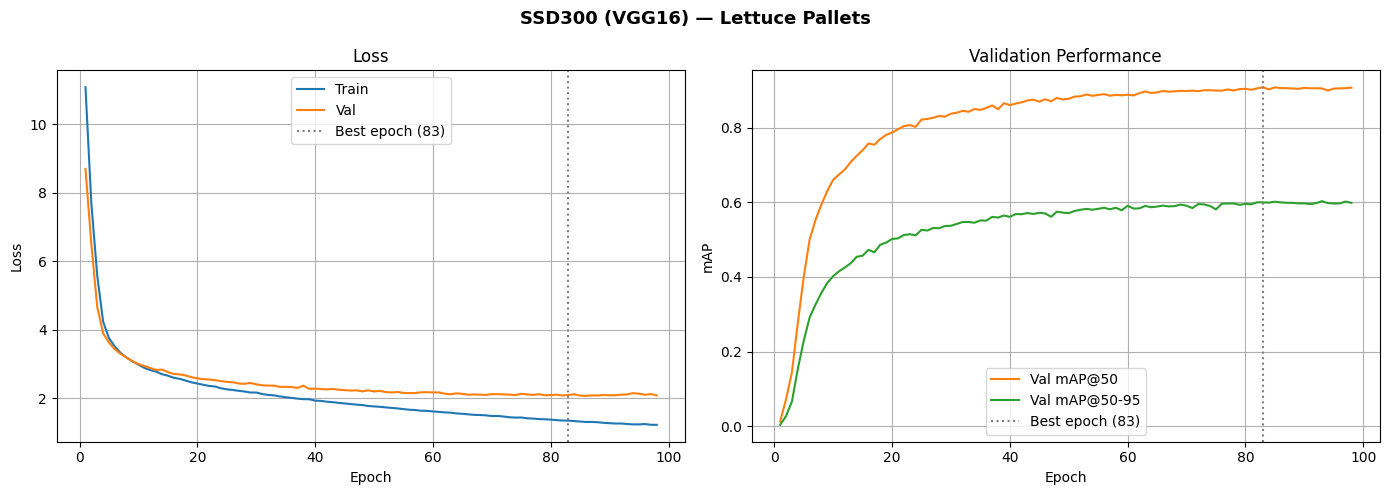

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x   = range(1, len(ssd_history["train_loss"]) + 1)
best_epoch = int(np.argmax(ssd_history["val_map50"])) + 1

ax1.plot(epochs_x, ssd_history["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, ssd_history["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_x, ssd_history["train_map50"], label="Train mAP@50", color="tab:blue")
ax2.plot(epochs_x, ssd_history["val_map50"],   label="Val mAP@50",   color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax2.set(xlabel="Epoch", ylabel="mAP@50", title="mAP@50")
ax2.legend()
ax2.grid(True)

plt.suptitle("SSD300 (VGG16) — Lettuce Pallets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SSD_RUNS_DIR / "training_curves.png", dpi=150)
plt.show()

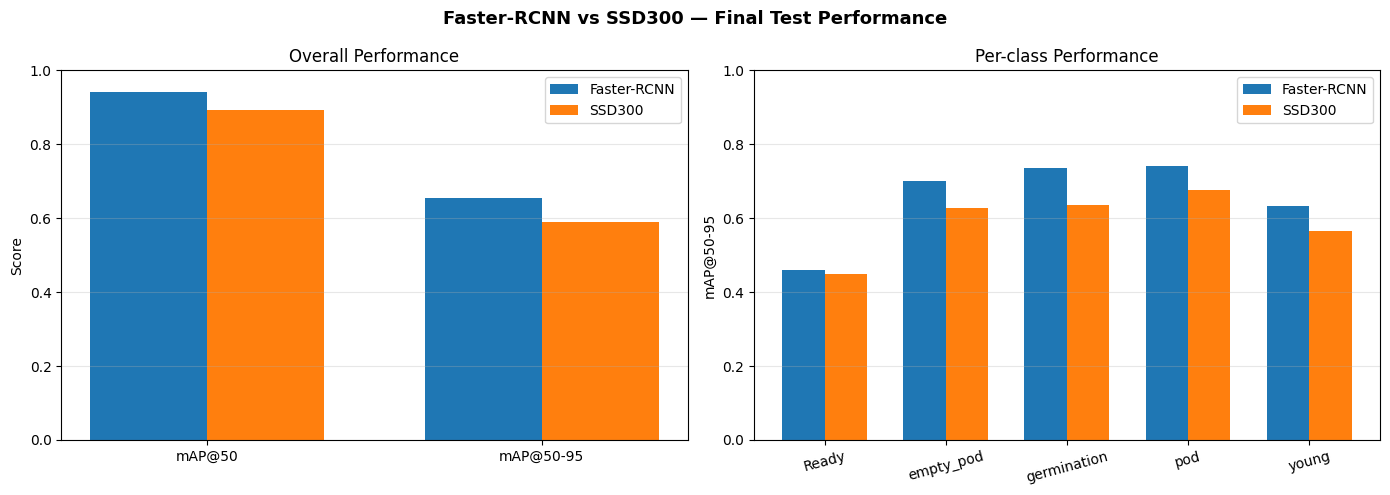

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.35

# Overall mAP
metrics_labels = ["mAP@50", "mAP@50-95"]
frcnn_overall  = [test_metrics["map_50"].item(), test_metrics["map"].item()]
ssd_overall    = [ssd_test_metrics["map_50"].item(), ssd_test_metrics["map"].item()]

x = np.arange(len(metrics_labels))
axes[0].bar(x - width/2, frcnn_overall, width, label="Faster-RCNN", color="tab:blue")
axes[0].bar(x + width/2, ssd_overall,   width, label="SSD300",      color="tab:orange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].set_ylabel("Score")
axes[0].set_title("Overall Performance")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.3)

# Per-class mAP@50-95
frcnn_per_class = test_metrics["map_per_class"].tolist()
ssd_per_class   = ssd_test_metrics["map_per_class"].tolist()
x = np.arange(len(CLASS_NAMES[1:]))
axes[1].bar(x - width/2, frcnn_per_class, width, label="Faster-RCNN", color="tab:blue")
axes[1].bar(x + width/2, ssd_per_class,   width, label="SSD300",      color="tab:orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES[1:], rotation=15)
axes[1].set_ylabel("mAP@50-95")
axes[1].set_title("Per-class Performance")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Faster-RCNN vs SSD300 — Final Test Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/comparison.png", dpi=150)
plt.show()

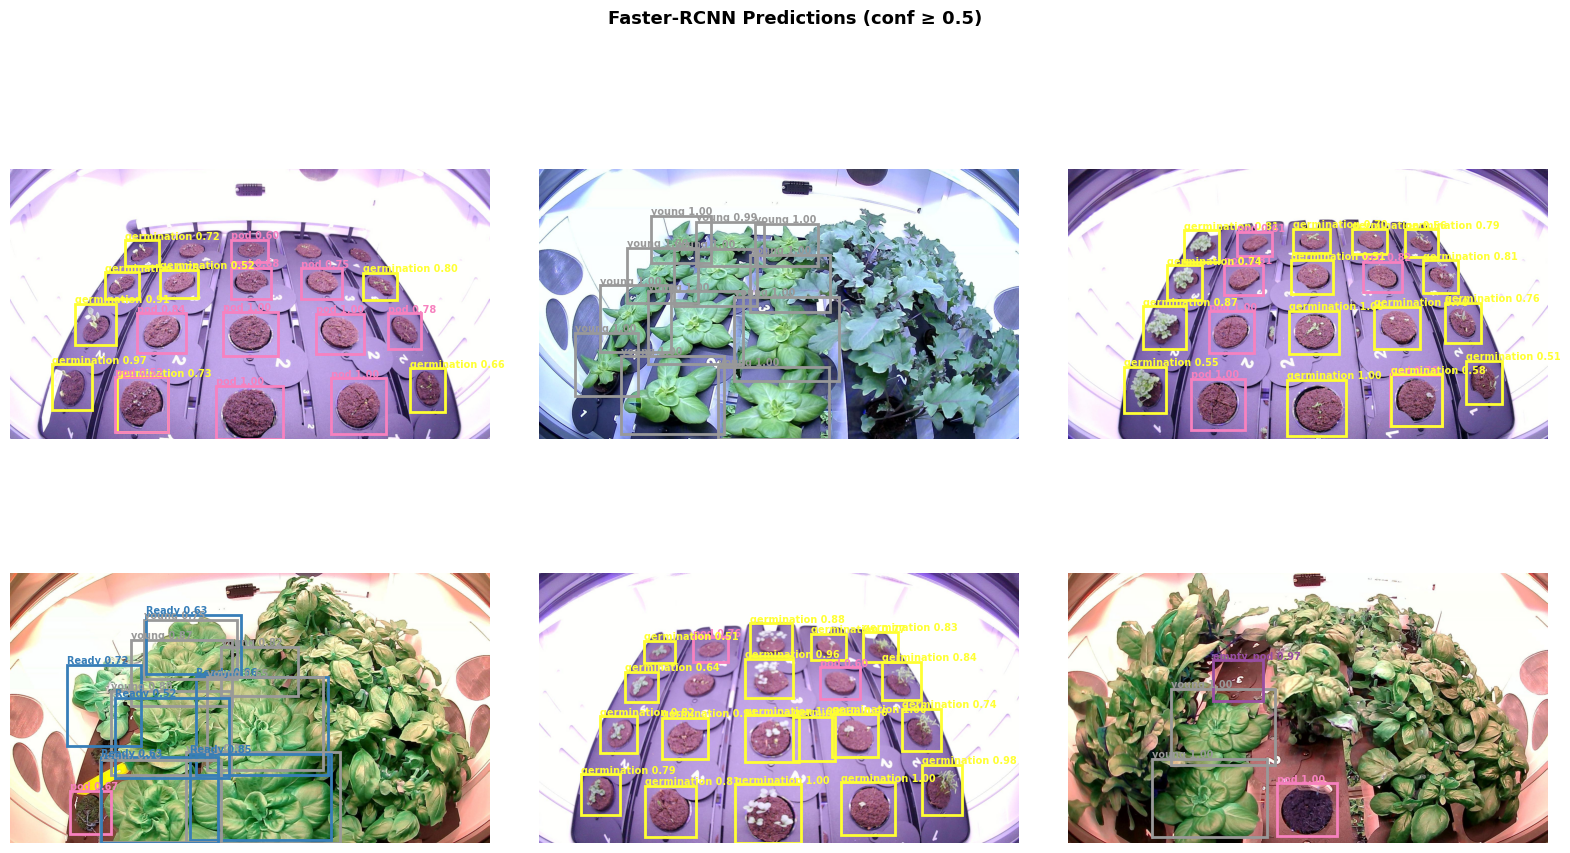

In [20]:
# Identical to Faster-RCNN visualisation — reuses plot_predictions()
plot_predictions(ssd_model, ssd_test_ds)